# Laboratorio 8
## Ejercicio 1 - Filtrado Pasa Banda
### Caso
Un laboratorio de ingeniería biomédica desarrolla un monitor ECG portátil.

Las señales presentan múltiples componentes frecuenciales y se requiere aislar únicamente la banda cardíaca relevante.
### Actividad
Genere tres señales:

5 Hz

20 Hz

80 Hz

Diseñe un filtro pasa banda que permita únicamente: 15 Hz a 30 Hz


Presente: Señal temporal y FFT antes/después

In [38]:
#Librerias
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt


(0.0, 0.1)

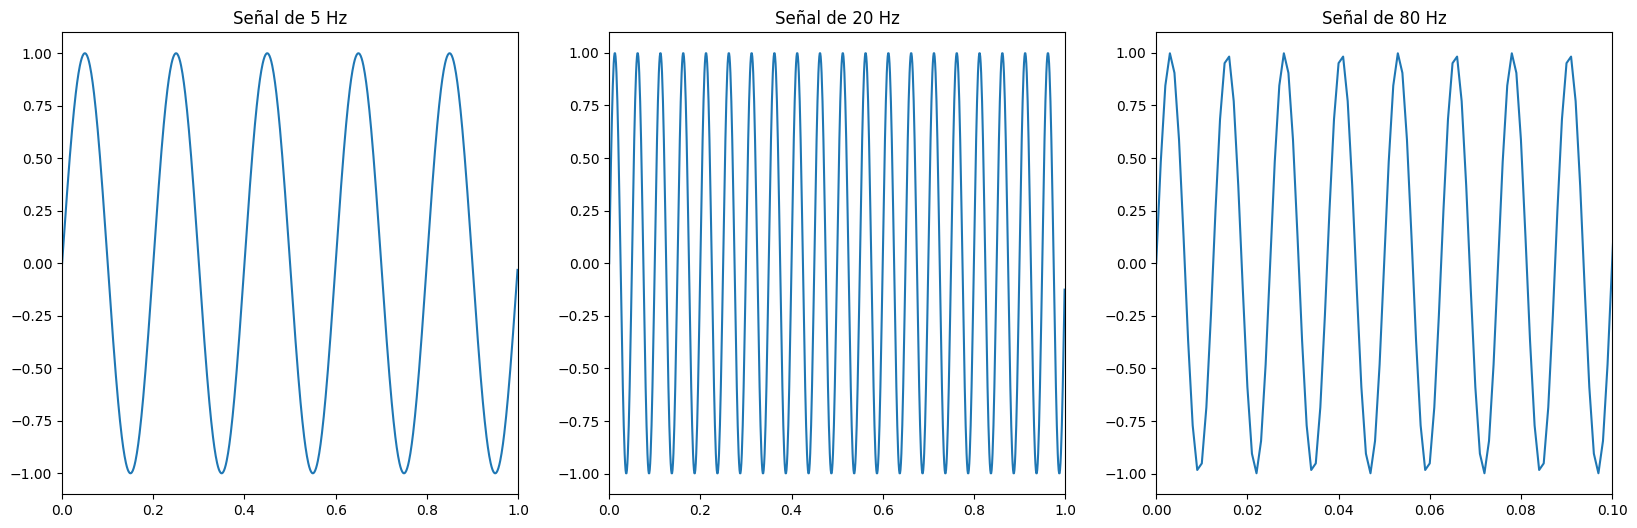

In [39]:
#Generación de señales
fs = 1000  # frecuencia de muestreo
t = np.arange(0, 1, 1/fs)
#Señales
# Señales
x1 = np.sin(2*np.pi*5*t)    # 5 Hz
x2 = np.sin(2*np.pi*20*t)   # 20 Hz
x3 = np.sin(2*np.pi*80*t)   # 80 Hz

plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.plot(t, x1)
plt.title("Señal de 5 Hz")
plt.xlim(0, 1)

plt.subplot(1,3,2)
plt.plot(t, x2)
plt.title("Señal de 20 Hz")
plt.xlim(0, 1)

plt.subplot(1,3,3)
plt.plot(t, x3)
plt.title("Señal de 80 Hz")
plt.xlim(0, 0.1)

Text(0, 0.5, 'Magnitude (dB)')

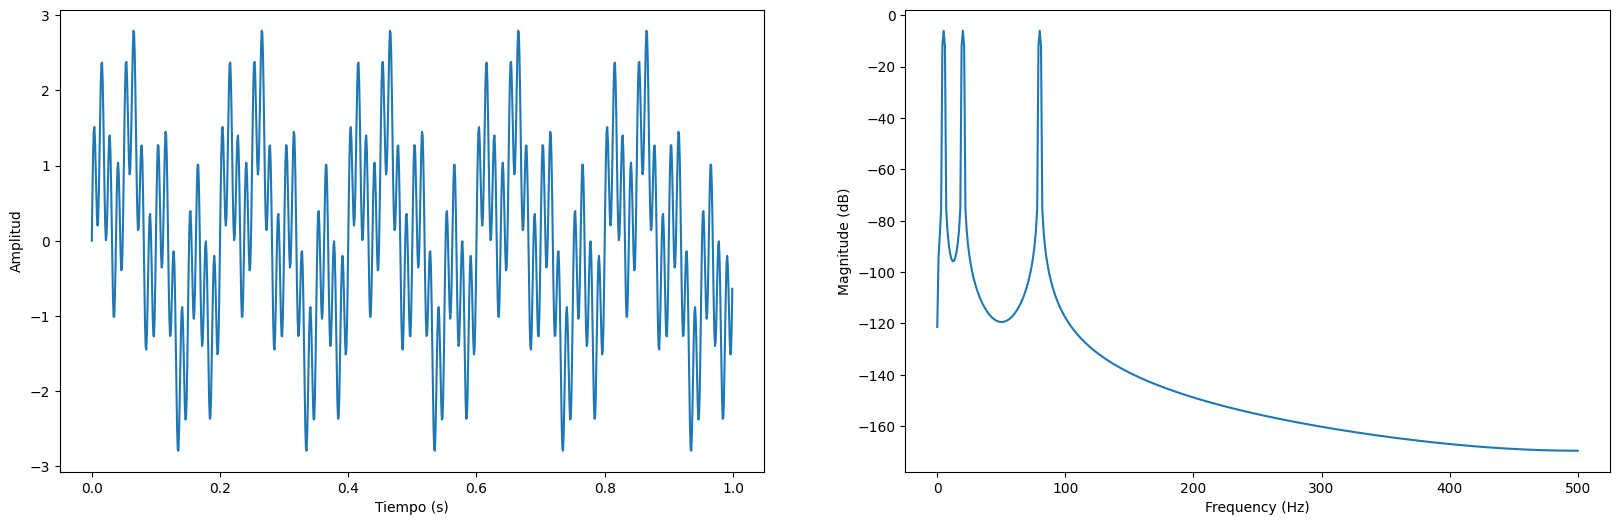

In [40]:
#Señal combinada
x = x1 + x2 + x3
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.subplot(1,2,2)
plt.magnitude_spectrum(x, Fs=fs,  scale='dB')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')

Text(0, 0.5, 'Magnitude (dB)')

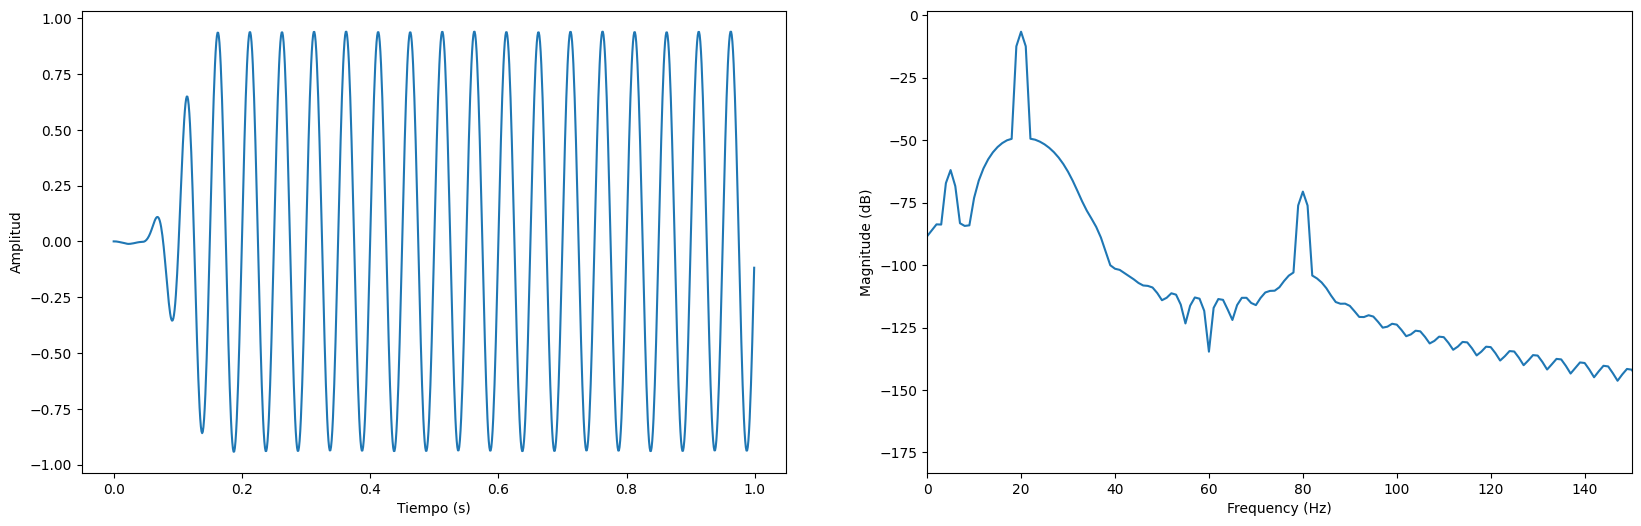

In [41]:
#Filtro pasa bandas
fc_hp = 15  #Corte inferior en 15 Hz
fc_lp = 30  #Corte superior en 30 Hz

fir = signal.firwin(
    201,
    [fc_hp, fc_lp],
    pass_zero=False,
    fs=fs
)
filtered = signal.lfilter(fir, 1.0, x)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(t, filtered)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.subplot(1,2,2)
plt.magnitude_spectrum(filtered, Fs=fs,  scale='dB')
plt.xlabel('Frequency (Hz)')
plt.xlim(0, 150)
plt.ylabel('Magnitude (dB)')

## Ejercicio 2 - Eliminación de ruido
### Caso
Un sistema de telemedicina transmite señales ECG desde zonas rurales.

Las señales presentan ruido blanco debido al sistema electrónico y transmisión inalámbrica.
### Actividad
Genere:
- ECG sintético
- ruido blanco
- interferencia de alta frecuencia

Diseñe:
- lowpass
- bandpass

In [42]:
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
fs = 1000
ts = 1/fs

In [43]:
#Generación de la señal ECG
ecg = nk.ecg_simulate(
    duration=10,
    sampling_rate=fs,
    heart_rate=70,
    noise = 0,  #El ruido se generará con otra función
)

In [44]:
#Ruido blanco
rb = np.random.normal(0,0.2,len(ecg))
ecg_noise = ecg + rb

In [45]:
#Ruido de alta frecuencia
f_noise = 80
noise_af = np.sin(2*np.pi*f_noise*np.arange(len(ecg))/fs)
ecg_noise = ecg_noise + noise_af

Para el diseño de los filtros. Al ser una señal ECG, la banda de interés es dentro del rango 0.5 a 40 Hz. Por tanto, mediante el lowpass se eliminará ruido de alta frecuencia superior a 40 Hz y mediante el bandpass se seteará la banda de interés

In [46]:
#Diseño de filtros
#Lowpass
fc = 40
n = 4
b,a = signal.butter(n, fc, btype='low', fs=fs)
ecg_filt = signal.filtfilt(b, a, ecg_noise)

# Bandpass
N = 101
fir_bp = signal.firwin(N, [0.5, 40], pass_zero=False, fs=fs)
ecg_filt = signal.lfilter(fir_bp, 1, ecg_filt)

Text(0.5, 1.0, 'Señal filtrada')

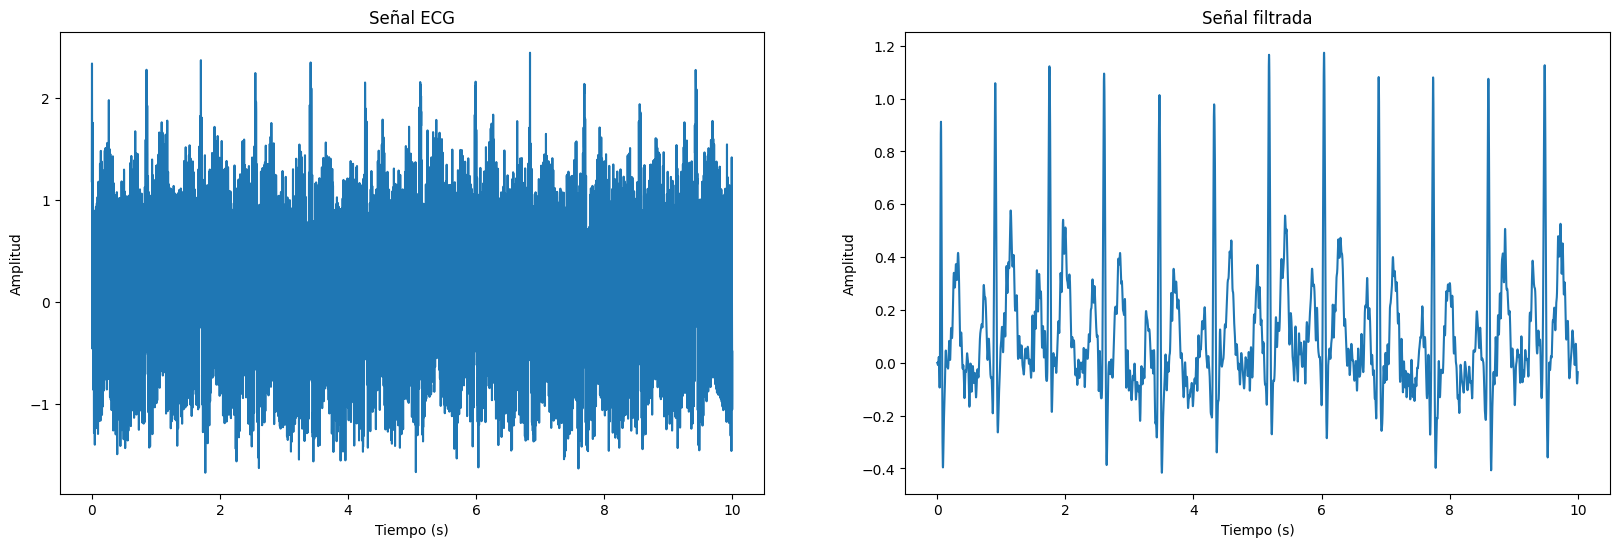

In [47]:
t = np.arange(0, 10, 1/fs)
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(t, ecg_noise)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG')
plt.subplot(1,2,2)
plt.plot(t, ecg_filt)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal filtrada')

## Ejercicio 3 - Rudio Impulsivo
### Caso
Durante un registro EEG aparecen desconexiones instantáneas de electrodos produciendo spikes abruptos.

### Actividad
Genere:
- señal EEG simulada
- 10 spikes aleatorios

Compare:
- FIR lowpass
- filtro mediana

Explique cuál funciona mejor

In [48]:
fs = 1000
t = np.arange(0,5,1/fs)

In [49]:
#Señal EEG (delta + alpha + beta)
eeg = (
    0.5*np.sin(2*np.pi*2*t) +   # delta
    1.0*np.sin(2*np.pi*10*t) +  # alpha
    0.3*np.sin(2*np.pi*20*t)    # beta
)

In [50]:
#Spikes aleatorios
np.random.seed(0)
spike_positions = np.random.randint(0, len(eeg), 10)
for i in spike_positions:
    eeg[i] += np.random.choice([-5,5])

In [51]:
#Filtro FIR Lowpass
N = 101
fir_lp = signal.firwin(N, 40, fs=fs)
eeg_fir = signal.filtfilt(fir_lp, 1, eeg)

In [52]:
#Filtro mediana
eeg_med = signal.medfilt(eeg, kernel_size=5)

Text(0.5, 1.0, 'Filtro de mediana')

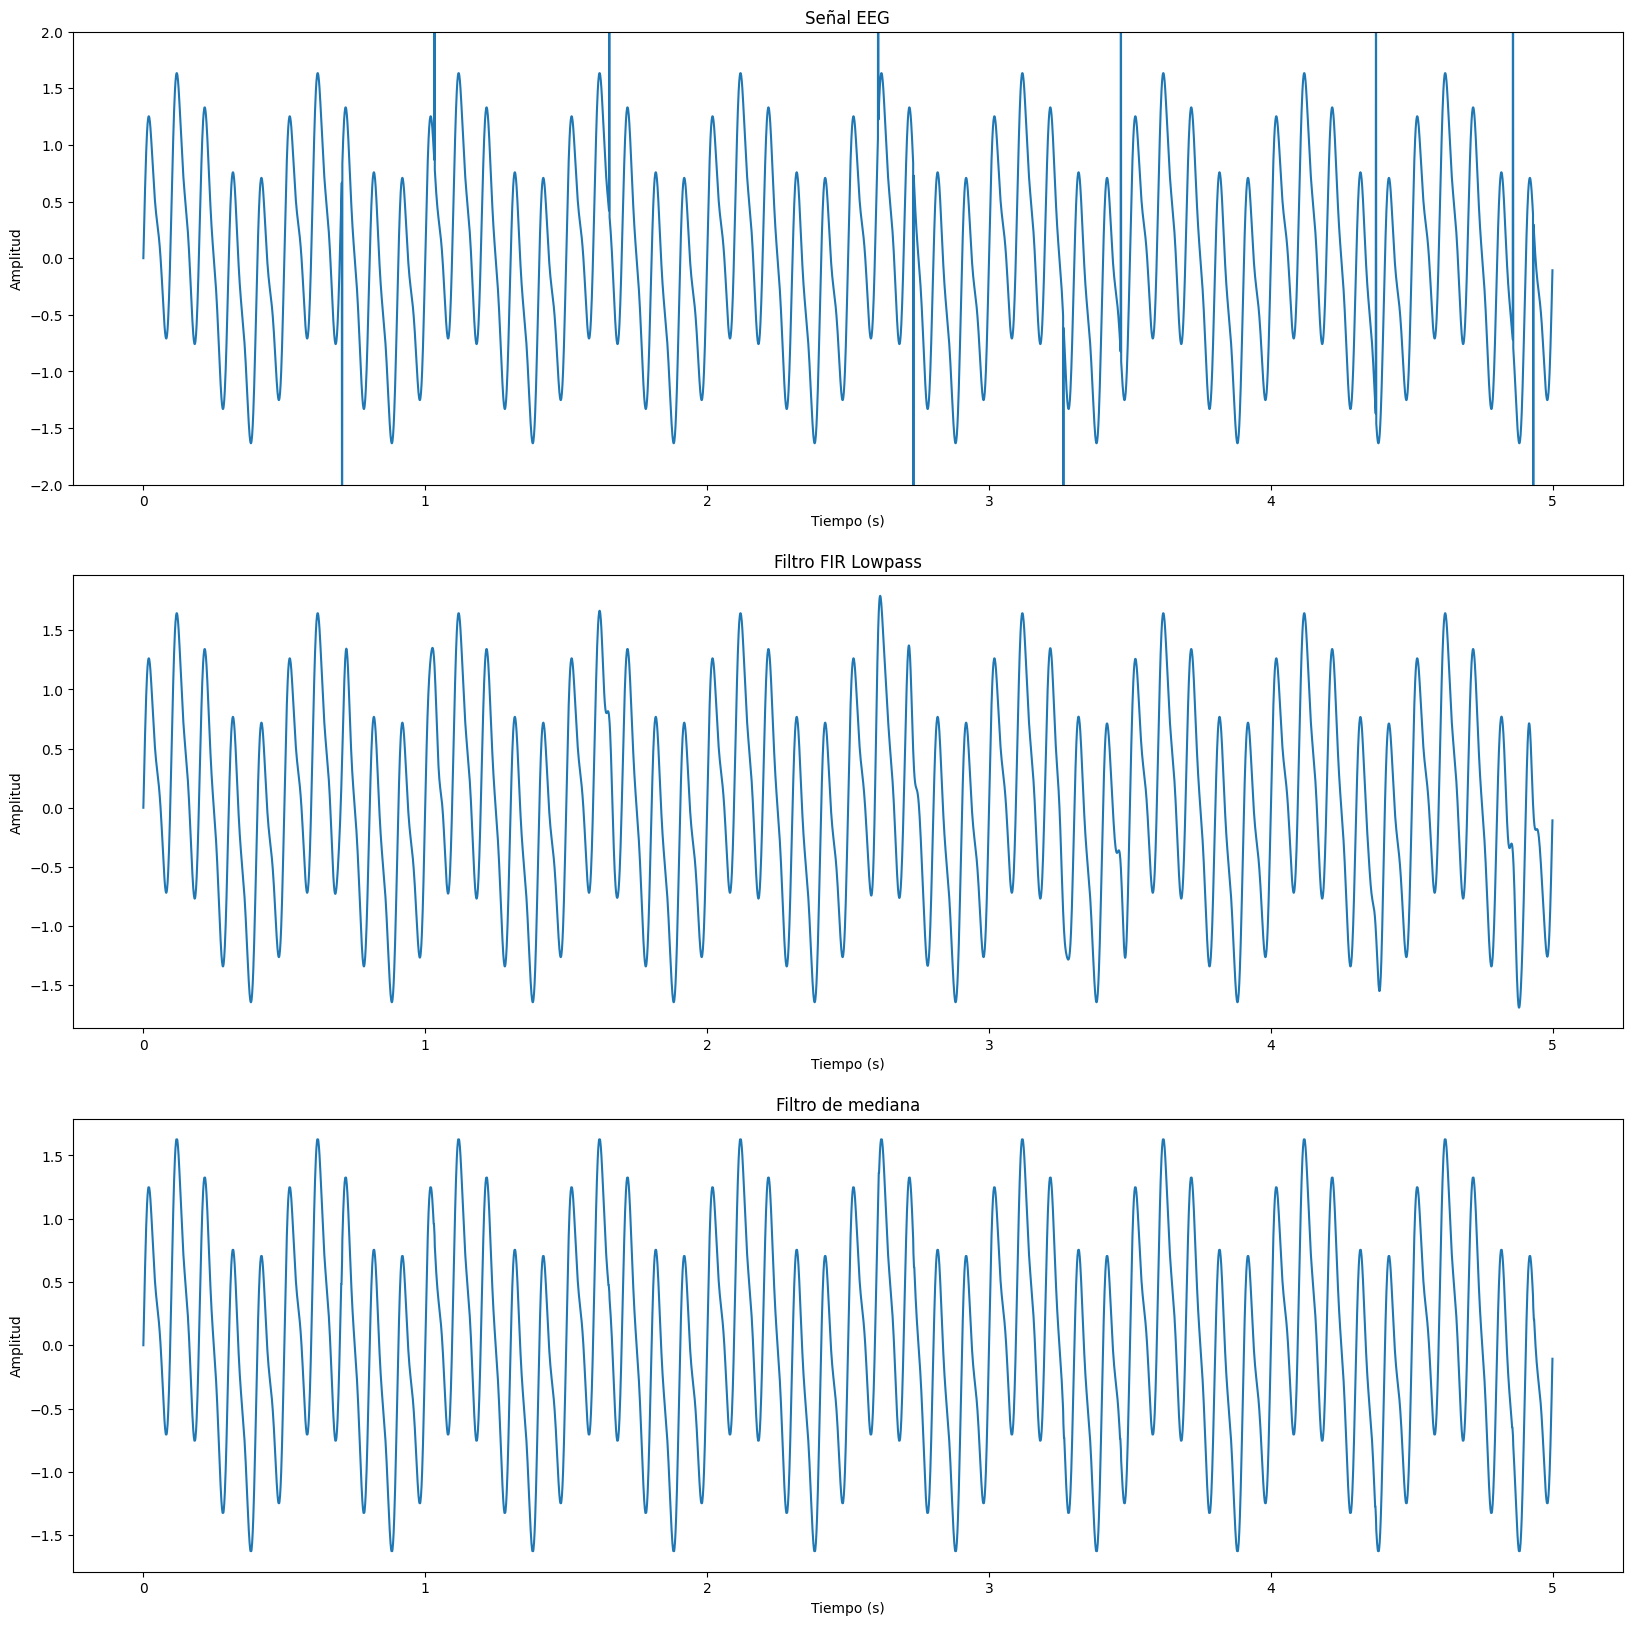

In [53]:
t = np.arange(0, 5, 1/fs)
plt.figure(figsize=(20,20))
plt.subplot(3,1,1)
plt.plot(t, eeg)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal EEG')
plt.ylim(-2,2)
plt.subplot(3,1,2)
plt.plot(t, eeg_fir)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Filtro FIR Lowpass')
plt.subplot(3,1,3)
plt.plot(t, eeg_med)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Filtro de mediana')

El filtro de mediana funciona mejor que el FIR low-pass para eliminar spikes, ya que estos son artefactos impulsivos (outliers) y no ruido de alta frecuencia. Mientras que el filtro FIR atenúa parcialmente los picos, el filtro de mediana los elimina eficazmente sin distorsionar significativamente la señal EEG.

## Ejercicio 4 - Interferencia eléctrica de 60 Hz
### Caso
Un monitor ECG hospitalario presenta interferencia causada por la red eléctrica.

### Actividad
Genere:
- ECG
- Ruido 60 Hz
- Ruido blanco

Diseñe un pipeline que elimine:
- interferencia eléctrica
- ruido de alta frecuencia


ECG Simulado  ----> Filtro Notch (60 Hz)  -----> Filtro Low-pass ------> ECG Limpio

Un pipeline clasico al momento de realizar el tratamiento clásico de una señal ECG

## Ejercicio 5 - Sensores Desincronizados
### Caso
Un wearable biomédico utiliza ECG, respiración y acelerómetro. Cada sensor inicia adquisición en tiempos diferentes

### Actividad
Genere:
- ECG
- respiración
- acelerómetro

Cada señal debe tener: delay distinto 2s y ruido gausiano. Sincronice todas usando correlación cruzada

In [54]:
t = np.arange(0,20,1/fs)
np.random.seed(0)
#ECG
ecg = nk.ecg_simulate(duration=20, sampling_rate=fs, noise=0)

#Respiración (baja frecuencia)
resp = np.sin(2*np.pi*0.25*t)

#Acelerometro (movimiento irregular)
acc = 0.5*np.sin(2*np.pi*1*t) + 0.2*np.random.randn(len(t))

In [55]:
#Delays
delay_ecg = int(2*fs)      # 2s
delay_resp = int(1.5*fs)
delay_acc = int(2.5*fs)

ecg = np.roll(ecg, delay_ecg)
resp = np.roll(resp, delay_resp)
acc = np.roll(acc, delay_acc)

In [56]:
#Ruido gaussiano
ecg += np.random.normal(0, 0.1, len(ecg))
resp += np.random.normal(0, 0.05, len(resp))
acc += np.random.normal(0, 0.1, len(acc))

In [57]:
#Correlacion cruzada
def estimar_delay(s1, s2):  #s1: señal de referencia
    corr = signal.correlate(s1, s2, mode='full')
    lag = np.argmax(corr) - len(s1)
    return lag

lag_resp = estimar_delay(ecg, resp)
lag_acc = estimar_delay(ecg, acc)

print("Delay respiración:", lag_resp)
print("Delay acelerómetro:", lag_acc)

Delay respiración: 1165
Delay acelerómetro: -15735


La correlación cruzada no estima correctamente el delay entre señales con morfologías diferentes, como ECG, respiración y acelerómetro, debido a la baja similitud entre ellas.

In [58]:
resp_sync = np.roll(resp, -lag_resp)
acc_sync = np.roll(acc, -lag_acc)
ecg_sync = ecg  # referencia

## Ejercicio 6 - Resampling Multisensor
### Caso
En una adquisición clínica:
- ECG se adquiere a 500 Hz
- respiración a 100 Hz
- temperatura a 200 Hz

Se requiere fusionar todas las señales.
### Actividad
Simule:
- ECG a 500 Hz
- respiración a 100 Hz
- acelerómetro a 200 Hz

Lleve todas las señales a: 500 Hz y sincronícelas temporalmente

In [60]:
#Frecuencias
fs_ecg = 500
fs_resp = 100
fs_acc = 200

duracion = 20

#Vectores temporales
t_ecg = np.arange(0,duracion,1/fs_ecg)
t_resp = np.arange(0,duracion,1/fs_resp)
t_acc = np.arange(0, duracion,1/fs_acc)

#Señales
ecg = nk.ecg_simulate(duration=duracion, sampling_rate=fs_ecg, noise=0)
resp = np.sin(2*np.pi*0.25*t_resp)
acc = 0.5*np.sin(2*np.pi*1*t_acc)

In [61]:
#delays
delay_ecg = int(1*fs_ecg)
delay_resp = int(2*fs_resp)
delay_acc = int(1.5*fs_acc)

ecg_d = np.roll(ecg, delay_ecg)
resp_d = np.roll(resp, delay_resp)
acc_d = np.roll(acc, delay_acc)

In [62]:
#Resampling a 500 Hz
# Número de muestras objetivo
N_target = len(ecg_d)

resp_resampled = signal.resample(resp_d, N_target)
acc_resampled = signal.resample(acc_d, N_target)

ecg_resampled = ecg_d  # ya está en 500 Hz

In [63]:
#Sincronización
lag_resp = estimar_delay(ecg_resampled, resp_resampled)         #Función usada en otro inciso
lag_acc = estimar_delay(ecg_resampled, acc_resampled)

In [64]:
#Alinear señales
resp_sync = np.roll(resp_resampled, -lag_resp)
acc_sync = np.roll(acc_resampled, -lag_acc)
ecg_sync = ecg_resampled

De manera similar al caso anterior, la correlación puede fallar por no poder usar una señal base del mismo tipo ()en este caso se usa la señal ecg como base, por lo que al determinar el delay de resp o acc, estos pueden fallar por no fitear correctamente con la señal ecg